In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
df = pd.read_csv("Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


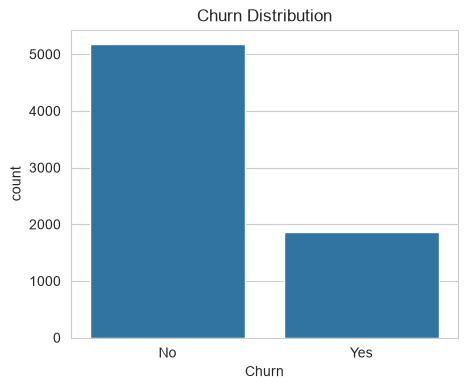

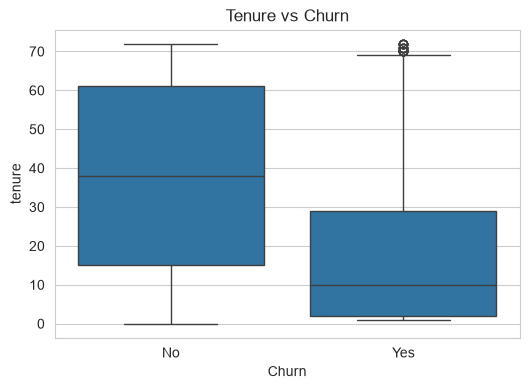

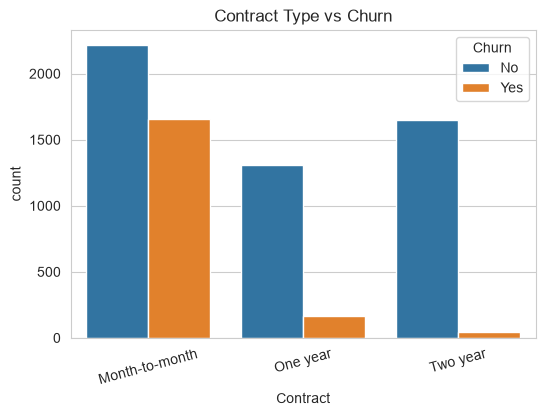

Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['Contract', 'Dependents', 'DeviceProtection', 'InternetService', 'MultipleLines', 'OnlineBackup', 'OnlineSecurity', 'PaperlessBilling', 'Partner', 'PaymentMethod', 'PhoneService', 'SeniorCitizen', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'gender']


In [ ]:


sns.set_style("whitegrid")

# 1. Churn distribution
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

# 2. Tenure vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

# 3. Contract type vs Churn
plt.figure(figsize=(6,4))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

























df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df.drop(columns=["customerID"], inplace=True)

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop(columns=["Churn"])
y = df["Churn"]

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = X.columns.difference(numeric_features).tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

In [17]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])


pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [ ]:
param_grid_lr = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"]
}

param_grid_rf = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5, scoring="f1", n_jobs=-1)
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5, scoring="f1", n_jobs=-1)

grid_lr.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Best RF params:", grid_rf.best_params_)


c:\Users\Lenovo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best LR params: {'classifier__C': 10, 'classifier__penalty': 'l2'}
Best RF params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


--- Logistic Regression ---
Accuracy: 0.8055 | F1-score: 0.6040
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



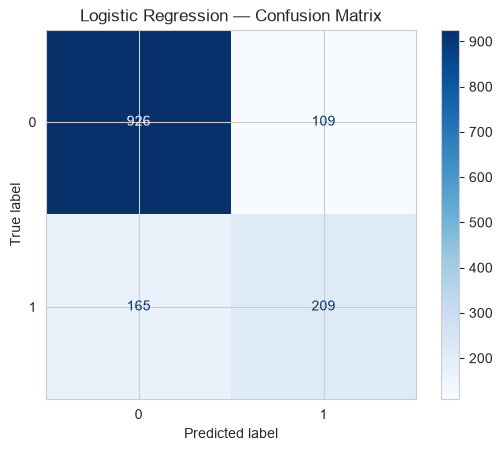

--- Random Forest ---
Accuracy: 0.7970 | F1-score: 0.5693
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



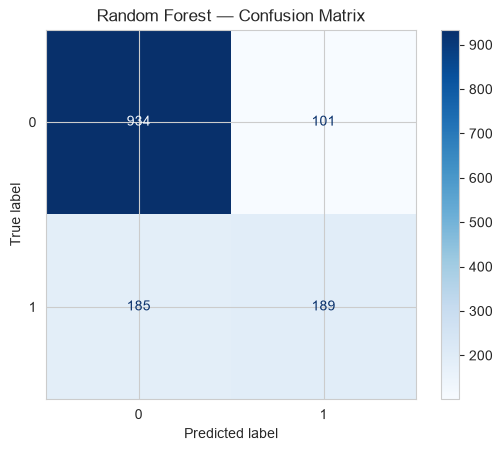

In [20]:
def evaluate(name, model, X_test, y_test):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f} | F1-score: {f1:.4f}")
    print(classification_report(y_test, preds))
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"{name} — Confusion Matrix")
    plt.show()
    return acc, f1

lr_acc, lr_f1 = evaluate("Logistic Regression", grid_lr.best_estimator_, X_test, y_test)
rf_acc, rf_f1 = evaluate("Random Forest", grid_rf.best_estimator_, X_test, y_test)

In [ ]:
best_model = grid_lr.best_estimator_ if lr_f1 >= rf_f1 else grid_rf.best_estimator_
best_name = "Logistic Regression" if lr_f1 >= rf_f1 else "Random Forest"

joblib.dump(best_model, "telco_churn_pipeline.joblib")
print(f"Saved best model ({best_name}) to telco_churn_pipeline.joblib")

loaded_model = joblib.load("telco_churn_pipeline.joblib")
sample = X_test.iloc[[0]]
print("Prediction:", loaded_model.predict(sample))
print("Actual label:", y_test.iloc[0])

Saved best model (Logistic Regression) to telco_churn_pipeline.joblib
Prediction: [0]
Actual label: 0


In [22]:
print(f"""
Final Summary
-------------
Best Logistic Regression F1: {lr_f1:.4f}
Best Random Forest F1:       {rf_f1:.4f}
Chosen model for deployment: {best_name}

Key churn drivers:
- Contract type (month-to-month churns most)
- Tenure (new customers churn more)
- Monthly charges (higher charges → higher churn risk)
""")


Final Summary
-------------
Best Logistic Regression F1: 0.6040
Best Random Forest F1:       0.5693
Chosen model for deployment: Logistic Regression

Key churn drivers:
- Contract type (month-to-month churns most)
- Tenure (new customers churn more)
- Monthly charges (higher charges → higher churn risk)

